<a href="https://colab.research.google.com/github/YEsh-DEV/Hunger/blob/main/NTLML_NACC_Tournment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Tournament Prediction Pipeline...
Data loaded successfully!
Model created Succsesfully
Average Log Loss across 5 folds: 0.5027
Average Brier Score across 5 folds: 0.1677
Average MSE across 5 folds: 0.1677
Average AUC (ROC) across 5 folds: 0.8312


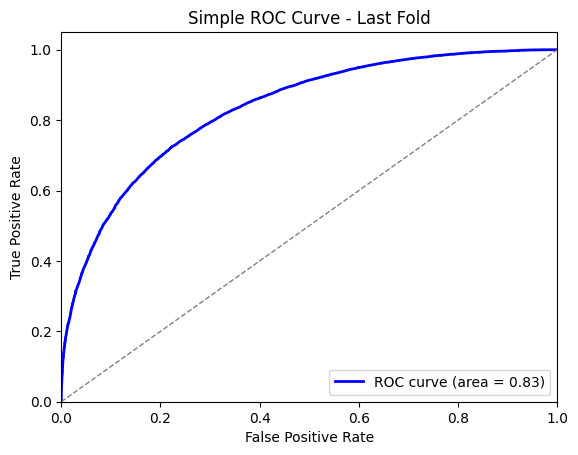

Model refit on entire training data for final submission prediction


<Figure size 800x500 with 0 Axes>

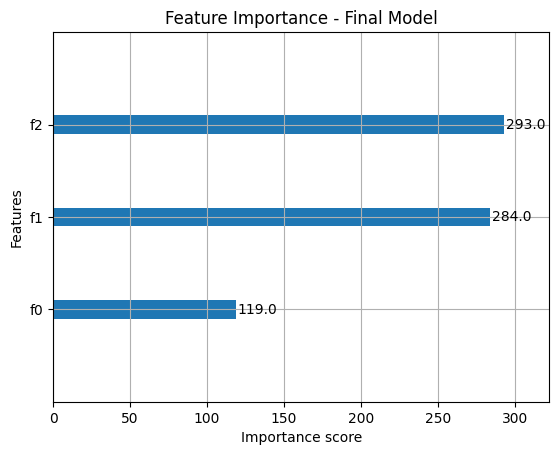

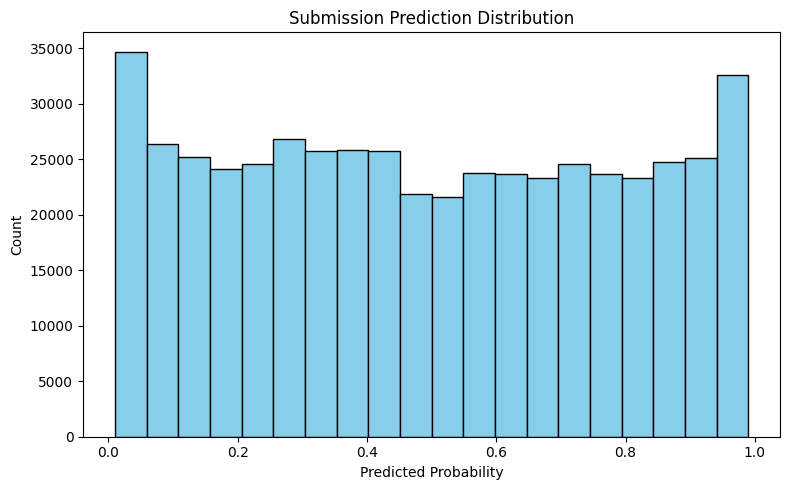

Submission saved to: submission1.csv
Average predicted probability: 0.4930
Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('xgb',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_lea

In [ ]:
import pandas as pd
import numpy as np
import glob
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss,brier_score_loss, mean_squared_error, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn import set_config
import matplotlib.pyplot as plt
import xgboost as xgb

class TournamentPredictor:
    def __init__(self, data_dir="/content/drive/MyDrive/NACC-DATA_2025/**"):
        self.data_path = data_dir
        self.data = {}
        self.seeds = {}
        self.games = None
        self.sub = None
        self.features = None
        self.model = None
        self.imputer = SimpleImputer(strategy='mean')
        self.scaler = StandardScaler()

    def load_data(self):
        """Load and prepare all data files"""
        files = glob.glob(self.data_path) # provides a consistent way to perform specific pattern-based file searching across different operating systems
        self.data = {file.split('/')[-1].split('.')[0]: pd.read_csv(file) for file in files}

        # Combining seeds and building seeds dictionary

        seeds_df = pd.concat([self.data['MNCAATourneySeeds'], self.data['WNCAATourneySeeds']])
        for _, row in seeds_df.iterrows():# This loop goes through every row in the DataFrame seeds_df,_ means we are ignoring the index of the row
            key = f"{row['Season']}_{row['TeamID']}"#This unique key will be used to identify the seed of a specific team in a specific season.
            seed_value = ''.join(filter(str.isdigit, row['Seed']))  # Extract  the numeric part of the seed e.g., from "W01" to "01").
            self.seeds[key] = int(seed_value) if seed_value else 16  # Default seed

        # Combineing all relevant game data into one DataFrame
        season_games = pd.concat([
            self.data['MRegularSeasonDetailedResults'],
            self.data['WRegularSeasonDetailedResults']
        ])
        tourney_games = pd.concat([
            self.data['MNCAATourneyDetailedResults'],
            self.data['WNCAATourneyDetailedResults']
        ])
        self.games = pd.concat([season_games, tourney_games])

        # Preparing submission data
        self.sub = self.data['SampleSubmissionStage1'].copy()

        print("Data loaded successfully!")

    def prepare_features(self):
        # Normalize team order so Team1 < Team2 for consistency
        self.games['Team1'] = self.games.apply(lambda r: min(r['WTeamID'], r['LTeamID']), axis=1)
        self.games['Team2'] = self.games.apply(lambda r: max(r['WTeamID'], r['LTeamID']), axis=1)

        # Unique game ID
        self.games['ID'] = self.games.apply(lambda r: f"{r['Season']}_{r['Team1']}_{r['Team2']}", axis=1)

        # Label target=1 if Team1 won, else 0
        self.games['Target'] = self.games.apply(lambda r: 1 if r['WTeamID'] == r['Team1'] else 0, axis=1)

        # Add seeds and seed difference
        self.games['Team1Seed'] = self.games.apply(
            lambda r: self.seeds.get(f"{r['Season']}_{r['Team1']}", 16), axis=1
        )
        self.games['Team2Seed'] = self.games.apply(
            lambda r: self.seeds.get(f"{r['Season']}_{r['Team2']}", 16), axis=1
        )
        self.games['SeedDiff'] = self.games['Team1Seed'] - self.games['Team2Seed']

        # Calculate average points scored per team per season
        # We use WScore for winners and LScore for losers to calculate average points per team in all games

        # Create a DataFrame with each team and its score for each game (both teams counted)
        team_scores_winner = self.games[['Season', 'WTeamID', 'WScore']].rename(
            columns={'WTeamID': 'TeamID', 'WScore': 'Score'})#winning team's info in a uniform format.
        team_scores_loser = self.games[['Season', 'LTeamID', 'LScore']].rename(
            columns={'LTeamID': 'TeamID', 'LScore': 'Score'})#Lossing team's info in a uniform format.

        team_scores = pd.concat([team_scores_winner, team_scores_loser])

        # Average points per team per season
        avg_points = team_scores.groupby(['Season', 'TeamID'])['Score'].mean().reset_index()
        avg_points.columns = ['Season', 'TeamID', 'AvgPoints']

        # Merge average points for Team1
        self.games = self.games.merge(avg_points, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left')
        self.games.rename(columns={'AvgPoints': 'Team1AvgPoints'}, inplace=True)
        self.games.drop('TeamID', axis=1, inplace=True)

        # Merge average points for Team2
        self.games = self.games.merge(avg_points, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left')
        self.games.rename(columns={'AvgPoints': 'Team2AvgPoints'}, inplace=True)
        self.games.drop('TeamID', axis=1, inplace=True)

        # Calculate difference in average points
        self.games['AvgPointsDiff'] = self.games['Team1AvgPoints'] - self.games['Team2AvgPoints']


        # Calculate average points allowed per team per season
        team_points_allowed_winner = self.games[['Season', 'WTeamID', 'LScore']].rename(
            columns={'WTeamID': 'TeamID', 'LScore': 'PointsAllowed'}) #This shows how many points the winning team allowed in each game.
        team_points_allowed_loser = self.games[['Season', 'LTeamID', 'WScore']].rename(
            columns={'LTeamID': 'TeamID', 'WScore': 'PointsAllowed'}) #This shows how many points the losing team allowed in each game.

        team_points_allowed = pd.concat([team_points_allowed_winner, team_points_allowed_loser]) #Now we have every team’s points allowed in every game (win or lose)

        # Average points allowed per team per season
        avg_points_allowed = team_points_allowed.groupby(['Season', 'TeamID'])['PointsAllowed'].mean().reset_index() #Calculates mean points allowed across all games
        avg_points_allowed.columns = ['Season', 'TeamID', 'AvgPointsAllowed'] #rename the clm

        # Merge average points allowed for Team1
        self.games = self.games.merge(avg_points_allowed, left_on=['Season', 'Team1'], right_on=['Season', 'TeamID'], how='left')
        self.games.rename(columns={'AvgPointsAllowed': 'Team1AvgPointsAllowed'}, inplace=True)
        self.games.drop('TeamID', axis=1, inplace=True)

        # Merge average points allowed for Team2
        self.games = self.games.merge(avg_points_allowed, left_on=['Season', 'Team2'], right_on=['Season', 'TeamID'], how='left')
        self.games.rename(columns={'AvgPointsAllowed': 'Team2AvgPointsAllowed'}, inplace=True)
        self.games.drop('TeamID', axis=1, inplace=True)

        # Calculate difference in average points allowed
        self.games['AvgPointsAllowedDiff'] = self.games['Team1AvgPointsAllowed'] - self.games['Team2AvgPointsAllowed']


        # Keep only recent seasons for training (2010+)
        self.games = self.games[self.games['Season'] >= 2010].reset_index(drop=True)

        # Prepare submission features
        self.sub['Season'] = self.sub['ID'].str.split('_').str[0].astype(int)
        # Convert team IDs to int to match seeds dictionary
        self.sub['Team1'] = self.sub['ID'].str.split('_').str[1].astype(int)
        self.sub['Team2'] = self.sub['ID'].str.split('_').str[2].astype(int)

        self.sub['Team1Seed'] = self.sub.apply(
            lambda r: self.seeds.get(f"{r['Season']}_{r['Team1']}", 16), axis=1
        )
        self.sub['Team2Seed'] = self.sub.apply(
            lambda r: self.seeds.get(f"{r['Season']}_{r['Team2']}", 16), axis=1
        )
        self.sub['SeedDiff'] = self.sub['Team1Seed'] - self.sub['Team2Seed']

        # Calculate average points for submission teams using avg_points DataFrame
        # Convert avg_points to dictionary for quick lookup
        avg_points_dict = {(row['Season'], row['TeamID']): row['AvgPoints'] for _, row in avg_points.iterrows()}#This line creates a dictionary such as :- (2025, 1001): 78.2

        def get_avg_points(season, team):
            return avg_points_dict.get((season, team), 75)  # Use 75 as default if team/season missing It’s likely an average scoring benchmark

        self.sub['Team1AvgPoints'] = self.sub.apply(
            lambda r: get_avg_points(r['Season'], r['Team1']), axis=1)
        self.sub['Team2AvgPoints'] = self.sub.apply(
            lambda r: get_avg_points(r['Season'], r['Team2']), axis=1) #Adds columns with each team's average points scored
        self.sub['AvgPointsDiff'] = self.sub['Team1AvgPoints'] - self.sub['Team2AvgPoints'] #Interpretation Positive = Team1 is a better scorer Negative = team2 is better scorer


        # Calculating  average points allowed for submission teams using avg_points_allowed DataFrame
        avg_points_allowed_dict = {(row['Season'], row['TeamID']): row['AvgPointsAllowed'] for _, row in avg_points_allowed.iterrows()}

        def get_avg_points_allowed(season, team):
            return avg_points_allowed_dict.get((season, team), 75) # Use 75 as default if team/season missing

        self.sub['Team1AvgPointsAllowed'] = self.sub.apply(
            lambda r: get_avg_points_allowed(r['Season'], r['Team1']), axis=1)
        self.sub['Team2AvgPointsAllowed'] = self.sub.apply(
            lambda r: get_avg_points_allowed(r['Season'], r['Team2']), axis=1)
        self.sub['AvgPointsAllowedDiff'] = self.sub['Team1AvgPointsAllowed'] - self.sub['Team2AvgPointsAllowed']#Interpretation Positive = Team1 is a better scorer Negative = team2 is better scorer


        # Final features list
        self.features = ['SeedDiff', 'AvgPointsDiff', 'AvgPointsAllowedDiff']

    def create_model(self):
        """Create a simple XGBoost model"""
        self.model = Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler()),
            ('xgb', xgb.XGBClassifier(
            n_estimators=100,#More trees = potentially more learning power (but slower & more prone to overfitting)
            max_depth=3,#Smaller depth = more regularization (less chance of overfitting)
            learning_rate=0.1,#Smaller values = slower learning, but often more accurate
            random_state=42,#Sets the random seed
            eval_metric='logloss'#Because this is a binary classification problem (predicting the probability )

            ))
        ])
        print("Model created Succsesfully")

    def train_model(self, n_splits=5):
        """Train and evaluate the model with K-Fold cross-validation"""
        X = self.games[self.features]
        y = self.games['Target']

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        log_losses = []
        brier_scores = []
        mses = []
        aucs = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1): #For each fold, you get training and validation indices
            X_train, X_val = X.i2loc[train_idx], X.iloc[val_idx]#.iloc[] is used in Pandas to select rows by integer position (like array index).
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]#here .iloc[] lets you extract those specific rows from the original X and y data.

            # Training model
            self.model.fit(X_train, y_train)

            # Predicting & evaluating
            val_preds = np.clip(self.model.predict_proba(X_val)[:, 1], 0.01, 0.99)
            loss = log_loss(y_val, val_preds)
            brier = brier_score_loss(y_val, val_preds)
            mse = mean_squared_error(y_val, val_preds)
            fpr, tpr, _ = roc_curve(y_val, val_preds)
            roc_auc = auc(fpr, tpr)

            log_losses.append(loss)
            brier_scores.append(brier)
            mses.append(mse)
            aucs.append(roc_auc)

        avg_loss = np.mean(log_losses)
        avg_brier = np.mean(brier_scores)
        avg_mse = np.mean(mses)
        avg_auc = np.mean(aucs)

        print(f"Average Log Loss across {n_splits} folds: {avg_loss:.4f}")
        print(f"Average Brier Score across {n_splits} folds: {avg_brier:.4f}")
        print(f"Average MSE across {n_splits} folds: {avg_mse:.4f}")
        print(f"Average AUC (ROC) across {n_splits} folds: {avg_auc:.4f}")


        # Ploting simple ROC curve for the last fold
        plt.figure()
        plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')#the line of no-skill (random guessing) Useful for comparison.
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Simple ROC Curve - Last Fold') # Changed title
        plt.legend(loc="lower right")#bottom-right corner.
        plt.show()

        # After cross-validation, refiting the full data in the model
        self.model.fit(X, y)
        print("Model refit on entire training data for final submission prediction")

        #Ploting the Feature Importance
        plt.figure(figsize=(8, 5))
        xgb.plot_importance(self.model.named_steps['xgb'], importance_type='weight')
        plt.title("Feature Importance - Final Model")
        plt.show()

    def predict_submission(self, output_file='submission1.csv'):
        """Generate submission predictions"""
        preds = np.clip(self.model.predict_proba(self.sub[self.features])[:, 1], 0.01, 0.99)
        self.sub['Pred'] = preds
        self.sub[['ID', 'Pred']].to_csv(output_file, index=False)

        # Plot distribution of predictions
        plt.figure(figsize=(8, 5))
        plt.hist(preds, bins=20, color='skyblue', edgecolor='black')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Count')
        plt.title('Submission Prediction Distribution')
        plt.tight_layout()
        plt.show()

        print(f"Submission saved to: {output_file}")
        print(f"Average predicted probability: {preds.mean():.4f}")

        # Diagram visualization of Model Pipeline
        set_config(display='diagram')
        print(self.model)

    def run(self):
        """Run full pipeline"""
        print("Starting Tournament Prediction Pipeline...")
        self.load_data()
        self.prepare_features()
        self.create_model()
        self.train_model()
        self.predict_submission()
        print("Pipeline completed successfully!")

# Runing pipeline
if __name__ == "__main__":
    predictor = TournamentPredictor(data_dir="/content/drive/MyDrive/NACC-DATA_2025/**")
    predictor.run()